## Task 4: Latent Space Analysis and Error Inspection

In this task, you will analyze the internal feature representation learned by the best model obtained in Task 3. Deep neural networks transform input images into increasingly abstract representations through multiple layers. The output of the final hidden layer before the classification layer can be interpreted as a latent feature representation of the images.

By visualizing this latent space, it is possible to gain insights into how the model organizes the data and why certain samples may be misclassified.

Create a new notebook named `latentspace.ipynb`. Use the best performing model from Task 3.

### 1. Load the trained model
- Load the best model obtained.
- Ensure the model is set to evaluation mode.
- Modify the network so that it outputs the feature vector from the last hidden layer instead of the final classification layer.

### 2. Extract latent representations
- Pass all images from the validation or test dataset through the model.
- For each image, extract the latent feature vector from the last hidden layer.
- Store for each sample:
  - the (flattened) latent feature vector,
  - the ground-truth label,
  - the predicted label,
  - the prediction confidence.

### 3. Dimensionality reduction
- Since the latent vectors are high-dimensional, reduce their dimensionality to two dimensions for visualization.
- Apply the following methods:
  - PCA
  - t-SNE
- Plot the 2D latent space obtained with both methods.
- Color the samples according to their ground-truth class label.

### 4. Comparison of PCA and t-SNE
- Compare the latent space structure obtained with PCA and t-SNE.
- Investigate whether the classes appear more clearly separated with one method than the other.

### 5. Inspection of misclassified samples
- Display several misclassified test images along with:
  - their ground-truth label,
  - the predicted label,
  - the prediction confidence.
- Compare these samples with nearby correctly classified samples in the latent space.

---

In your report, discuss the results of this analysis and address the following points:

- **Latent space structure:** Do healthy knees and severe osteoarthritis cases form distinct clusters in the latent space?
- **Dimensionality reduction methods:** What differences do you observe between the PCA and t-SNE visualizations? Describe your observations regarding the latent space structure.
- **Misclassified samples:** Where do misclassified samples appear in the latent space?
- **Interpretation:** What can these observations tell you about the model's behavior and the intrinsic difficulty of the classification task?

# 1. Select a Trained Classifier — Baseline CNN

We use the best-performing baseline CNN from Task 2 (lr=0.001, dropout=0.5, trained on train+val, 30 epochs).

In [ ]:
import sys

sys.path.insert(0, "../0_generalcode")
from gpu_helper import settest_torch_gpu

device = settest_torch_gpu()

PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Keras backend: tensorflow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediction shape: (5, 1)  — Keras is running on tensorflow , device: cuda


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, accuracy_score
import os

In [ ]:
DATA_DIR = "../../data/2_downsampled/"

transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ]
)

test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {test_dataset.classes}")

Test samples: 146
Classes: ['0', '1']


In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc_block(x)
        return x

In [23]:
MODEL_PATH = "../2_basemodel/baseline_model.pth"

model = BaselineCNN(dropout_rate=0.5).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= 0.5).astype(int)

print(f"Test samples: {len(all_labels)}")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, all_preds):.4f}")

Test samples: 146
Accuracy: 0.9795
F1 Score: 0.9697


# 2. Extract Latent Representations

The **last hidden layer** is the 128-dimensional ReLU output of `fc_block[2]` —
the representation the network builds just before the final classification head.
We create a feature extractor by re-using the existing weights up to that layer.

In [25]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

In [ ]:
# Reuse trained weights; stop before the final Linear layer
# fc_block: [0]=Flatten  [1]=Linear(16384,128)  [2]=ReLU  [3]=Dropout  [4]=Linear(128,1)
feature_extractor = nn.Sequential(
    model.conv_block,
    model.fc_block[0],  # Flatten
    model.fc_block[1],  # Linear -> 128-dim
    model.fc_block[2],  # ReLU   -> latent vector
).to(device)
feature_extractor.eval()

all_features = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        feats = feature_extractor(images)
        all_features.extend(feats.cpu().numpy())

all_features = np.array(all_features)  # (N, 128)
print(f"Feature matrix: {all_features.shape}")
print(f"Labels shape  : {all_labels.shape}")

Feature matrix: (146, 128)
Labels shape  : (146,)


# 3. Dimensionality Reduction

We reduce the 128-dim latent vectors to 2D with **PCA** and **t-SNE** and
plot both embeddings coloured by ground-truth label.
Misclassified samples are additionally marked with a black cross (X).

In [ ]:
pca = PCA(n_components=2, random_state=42)
feats_pca = pca.fit_transform(all_features)
print(
    f"PCA explained variance: {pca.explained_variance_ratio_.round(3)} "
    f"(total {pca.explained_variance_ratio_.sum():.1%})"
)

PCA explained variance: [0.733 0.175] (total 90.8%)


In [28]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
feats_tsne = tsne.fit_transform(all_features)
print("t-SNE done")

t-SNE done


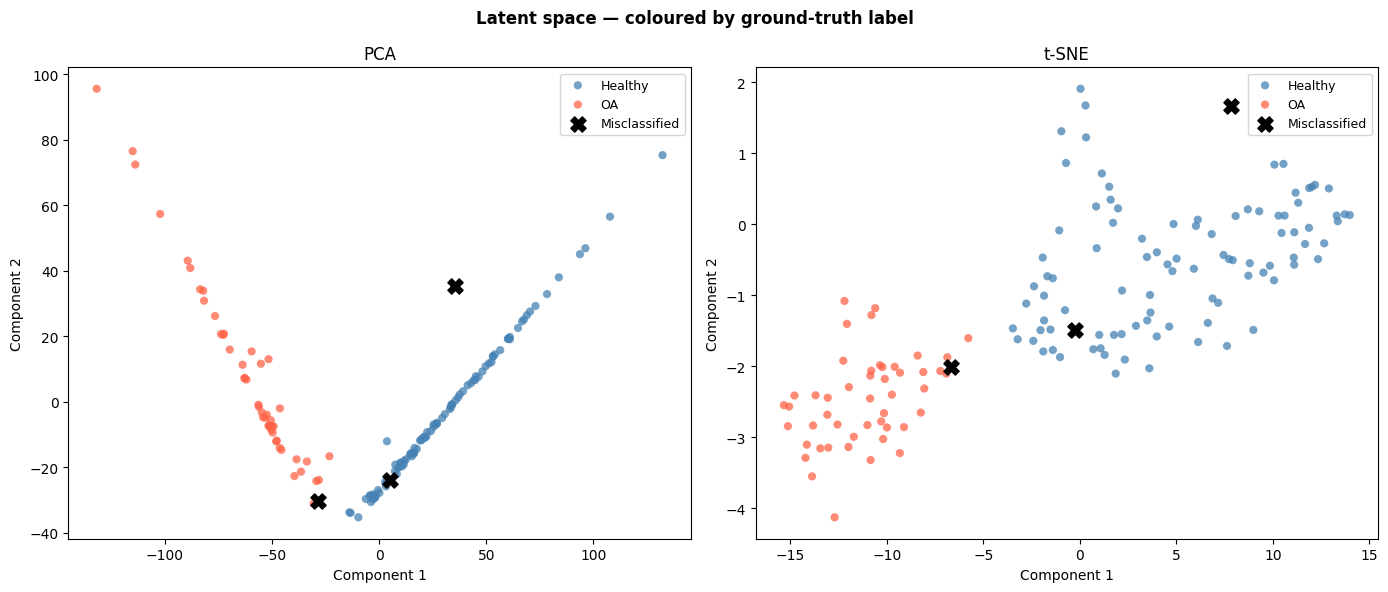

In [ ]:
CLASS_NAMES = ["Healthy", "OA"]
CLASS_COLORS = ["steelblue", "tomato"]
misc_mask = all_labels != all_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (emb, title) in zip(axes, [(feats_pca, "PCA"), (feats_tsne, "t-SNE")]):
    for cls, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
        m = all_labels == cls
        ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=color,
            label=name,
            alpha=0.75,
            s=35,
            edgecolors="none",
        )
    ax.scatter(
        emb[misc_mask, 0],
        emb[misc_mask, 1],
        marker="X",
        c="black",
        s=120,
        zorder=5,
        label="Misclassified",
    )
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.suptitle("Latent space — coloured by ground-truth label", fontweight="bold")
plt.tight_layout()
plt.show()

# 4. Comparison of PCA and t-SNE

| | PCA | t-SNE |
|---|---|---|
| **Preserves** | global variance / linear structure | local neighbourhood structure |
| **Class separation** | *fill in after running* | *fill in after running* |
| **Cluster compactness** | *fill in* | *fill in* |
| **Outliers visible** | *fill in* | *fill in* |

*Discuss here: which method shows clearer class separation and why that is expected given the nature of the two methods.*

# 5. Inspection of Misclassified Samples

We first display the misclassified images with ground-truth label, predicted label and confidence. Then we annotate their position in the latent space together with their **5 nearest neighbours** (searched in the original 128-dim feature space).

3 misclassified sample(s)


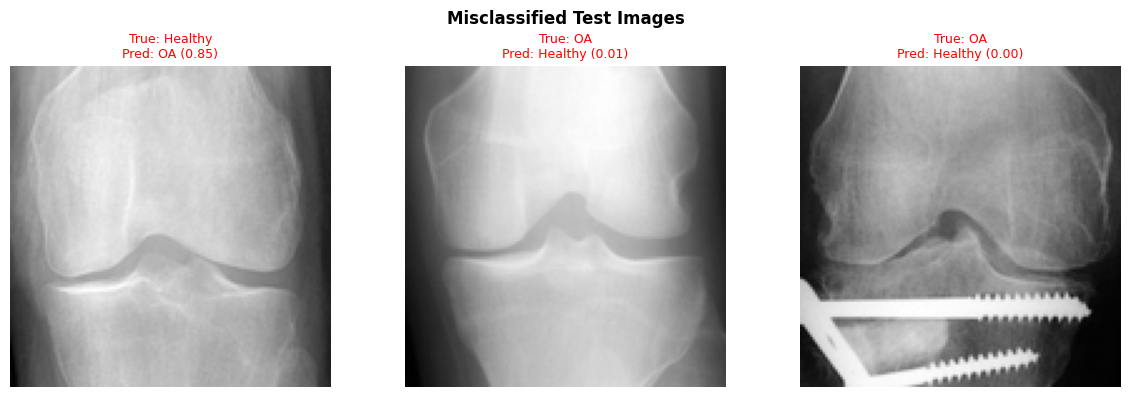

In [ ]:
# Unnormalised dataset for display
display_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ]
)
display_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=display_transform
)

misc_idx = np.where(misc_mask)[0]
print(f"{len(misc_idx)} misclassified sample(s)")

fig, axes = plt.subplots(1, len(misc_idx), figsize=(4 * len(misc_idx), 4))
if len(misc_idx) == 1:
    axes = [axes]

for ax, idx in zip(axes, misc_idx):
    img, _ = display_dataset[idx]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(
        f"True: {CLASS_NAMES[int(all_labels[idx])]}\n"
        f"Pred: {CLASS_NAMES[int(all_preds[idx])]} ({all_probs[idx]:.2f})",
        color="red",
        fontsize=9,
    )
    ax.axis("off")

plt.suptitle("Misclassified Test Images", fontweight="bold")
plt.tight_layout()
plt.show()

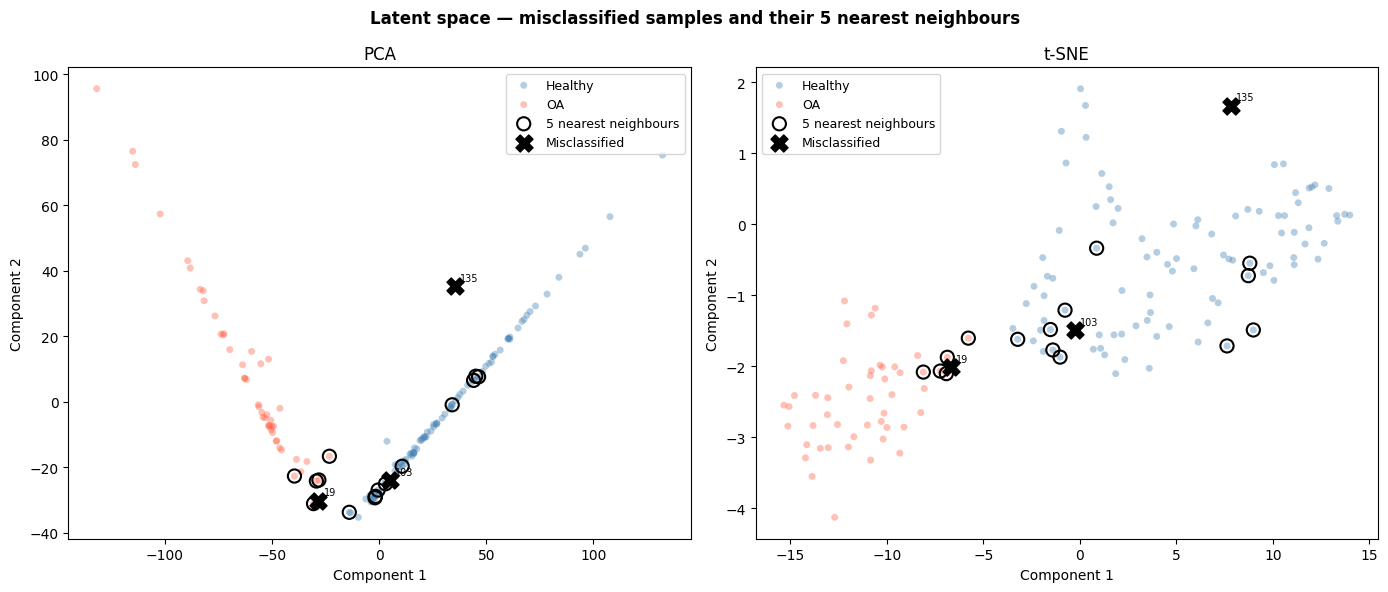

In [ ]:
# 5 nearest neighbours in 128-dim feature space
knn = NearestNeighbors(n_neighbors=6)  # 6 = self + 5 neighbours
knn.fit(all_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (emb, title) in zip(axes, [(feats_pca, "PCA"), (feats_tsne, "t-SNE")]):
    for cls, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
        m = all_labels == cls
        ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=color,
            alpha=0.4,
            s=25,
            edgecolors="none",
            label=name,
        )

    first = True
    for idx in misc_idx:
        _, nbr_idx = knn.kneighbors([all_features[idx]])
        nbrs = nbr_idx[0][1:]  # exclude self

        ax.scatter(
            emb[nbrs, 0],
            emb[nbrs, 1],
            facecolors="none",
            edgecolors="black",
            s=90,
            linewidths=1.5,
            label="5 nearest neighbours" if first else "",
        )
        ax.scatter(
            emb[idx, 0],
            emb[idx, 1],
            marker="X",
            c="black",
            s=150,
            zorder=6,
            label="Misclassified" if first else "",
        )
        ax.annotate(
            str(idx),
            emb[idx],
            fontsize=7,
            ha="left",
            xytext=(4, 4),
            textcoords="offset points",
        )
        first = False

    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.suptitle(
    "Latent space — misclassified samples and their 5 nearest neighbours",
    fontweight="bold",
)
plt.tight_layout()
plt.show()